# Polynomial Regression

Welcome to polynomial regression. This is an extension of linear regression that will make it predict way more accurately. By adding exponents to our features "x", we can achieve interesting functions that will fit our data.

Some things we need to know before continuing, is that adding higher value exponents to our polynomial, we will then get a super complex function that will result in our model `Overfitting` our data. This means, that outliers in our data will influence the model a lot. If we use no polynomials or not too many, this may result in `Underfitting`, which means that our model won't be able to predict accurately, and will miss a lot of training data points.

In machine learning terms, we can say:

- Overfit = "High Variance"
- Underfit = "High bias"


Let's see it visually:

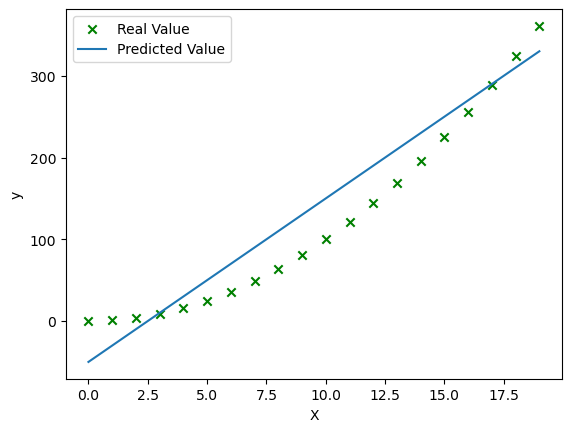

In [96]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 20, 1)
y = x**2

# Modelo de ejemplo
model_w = 20
model_b = -50

X = x.reshape(-1, 1)

pred = X * model_w + model_b

plt.scatter(x, y, marker='x', c='g', label='Real Value')
plt.plot(x, pred, label='Predicted Value')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

as we can see, the linear regression by itself will be a very bad fit for this data points. Lets see how to fix this.


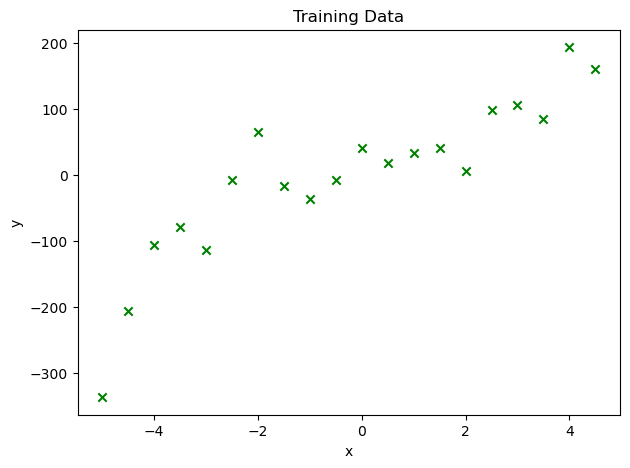

In [240]:
# Let's start creating our dataset

x = np.arange(-5, 5, 0.5)

#Artificial noise
noise = np.random.normal(0, 50, len(x))

y = 2*x**3 - 3*x**2 + 5*x + 20 + noise

plt.figure(figsize=(7,5))
plt.scatter(x, y, marker='x', c='g')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data")
plt.show()


We will apply feature engineering to our features. We have 20 features, so 20 rows and 1 column. Lets propose we use a 3rd grade polynomial. And recall, that if it underfits we can adjust the number of polynomials, and if it overfits we can reduce the number of polynomials.


In [241]:
#Feature engineering (3rd grade polynomial):
# Polynomial feature engineering (grado 12)
X = np.c_[
    x,
    x**2,
    x**3,
]

print(X[:5])
print(X.shape)

[[  -5.      25.    -125.   ]
 [  -4.5     20.25   -91.125]
 [  -4.      16.     -64.   ]
 [  -3.5     12.25   -42.875]
 [  -3.       9.     -27.   ]]
(20, 3)


## Feature Scaling

As we can see, we now have 3 features. we started with just one column, but we added two artificial ones. The third one is huge compared to the first one, meaning that our gradient descent wont work properly. For it to work properly, it needs our data to be in somewhat the same range of numbers. We can do this like:

$$X_{\text{norm}} = \frac{X - \mu}{\sigma}$$

In [242]:
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_norm = (X - mu)/sigma

print(X_norm[:5])



[[-1.64750894  2.20318283 -2.49189811]
 [-1.47408695  1.57370202 -1.78105138]
 [-1.30066495  1.01048235 -1.2118494 ]
 [-1.12724296  0.51352382 -0.76855384]
 [-0.95382097  0.08282642 -0.43542641]]


We can now see that all our features are very close! This will make gradient descent work really well and we will be able to find the minimum super fast!
Finally lets just implement our normal multivariable regression functions

In [243]:
def predict(X, w, b):
    
    return np.dot(X, w) + b

In [244]:
def compute_cost(X, y, w, b):

    m = X.shape[0]

    predictions = predict(X, w, b)

    cost = np.sum((predictions - y)**2)

    return cost/(2*m)

In [245]:
def compute_gradient(X, y, w, b):

    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0

    predictions = predict(X, w, b)

    error = predictions - y

    for j in range(n):

        dj_dw[j] = np.sum(error*X[:,j])/m

    dj_db = np.sum(error)/m

    return dj_dw, dj_db

In [246]:
def gradient_descent(X, y, w, b, alpha, iterations):

    J_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost = compute_cost(X, y, w, b)

        J_history.append(cost)

        if i % (iterations//10) == 0:

            print(f"Iteration {i}: Cost {cost:.2f}")

    return w, b, J_history

In [247]:
# Lets train our data
n = X_norm.shape[1]

w_init = np.zeros(n)
b_init = 0

alpha = 0.1
iterations = 10000

w_final, b_final, J_history = gradient_descent(
    X_norm,
    y,
    w_init,
    b_init,
    alpha,
    iterations
)

print("Weights:", w_final)
print("Bias:", b_final)

Iteration 0: Cost 4871.23
Iteration 1000: Cost 635.45
Iteration 2000: Cost 635.45
Iteration 3000: Cost 635.45
Iteration 4000: Cost 635.45
Iteration 5000: Cost 635.45
Iteration 6000: Cost 635.45
Iteration 7000: Cost 635.45
Iteration 8000: Cost 635.45
Iteration 9000: Cost 635.45
Weights: [ 11.67817739 -12.01059591  99.8125389 ]
Bias: -3.234506641172464


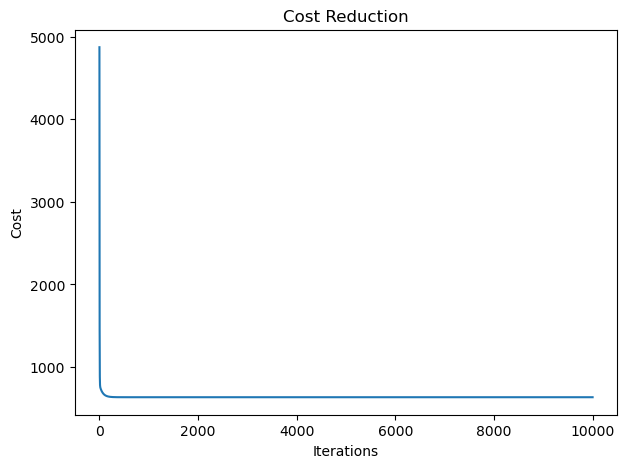

In [248]:
plt.figure(figsize=(7,5))

plt.plot(J_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction")

plt.show()

In [249]:
predictions = predict(X_norm, w_final, b_final)

In [250]:
sorted_indices = np.argsort(x)

x_sorted = x[sorted_indices]

pred_sorted = predictions[sorted_indices]

y_sorted = y[sorted_indices]

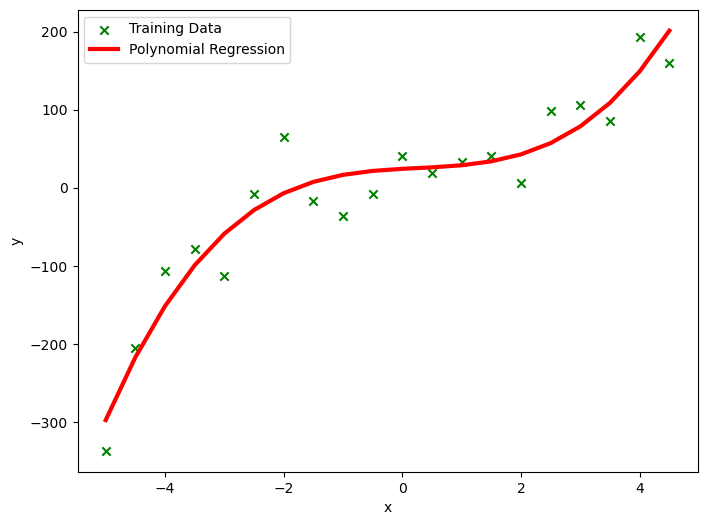

In [251]:
plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    marker='x',
    c='g',
    label='Training Data'
)

plt.plot(
    x_sorted,
    pred_sorted,
    c='r',
    linewidth=3,
    label='Polynomial Regression'
)

plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()

We can see that it fits our data nicely! You may go back and add features as you please, and see if it overfits. Play with the amount of data points, the amount of nth grade polynomials, or the noise variation to get a  Below is code so you can now enter a value x and see the prediction.

In [252]:
custom_x = float(input("Enter x value: "))

#You will need to add custom_x**n times to match your modified values
custom_features = np.array([
    custom_x,
    custom_x**2,
    custom_x**3
])

custom_features = (
    custom_features - mu
)/sigma

prediction = predict(
    custom_features.reshape(1,-1),
    w_final,
    b_final
)

print(
    f"Predicted y: {prediction[0]:.2f}"
)


Enter x value:  2


Predicted y: 42.69
